In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
##Load the dataset
df = pd.read_csv("../Dataset/CAR DETAILS FROM CAR DEKHO.csv")

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (4340, 8)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


In [5]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(763)

In [ ]:
##Check categorical values
print("Fuel Types:")
print(df["fuel"].value_counts())

print("\nSeller Types:")
print(df["seller_type"].value_counts())

print("\nTransmission:")
print(df["transmission"].value_counts())

print("\nOwner:")
print(df["owner"].value_counts())

Fuel Types:
fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64

Seller Types:
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64

Transmission:
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

Owner:
owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


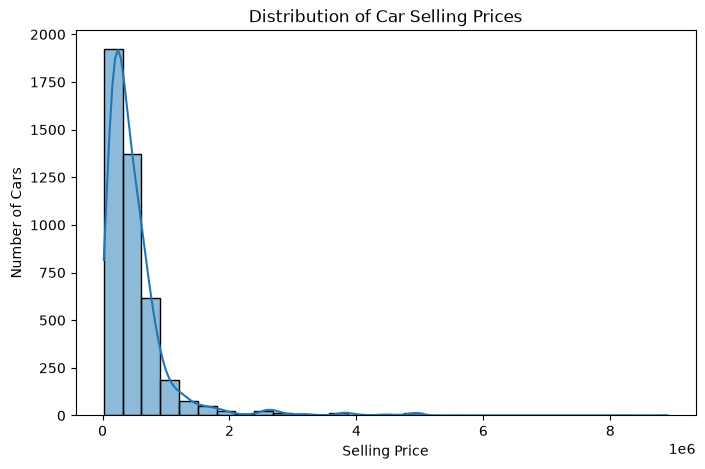

In [9]:
## Basic EDA 📊

##Selling price distribution ##
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.show()

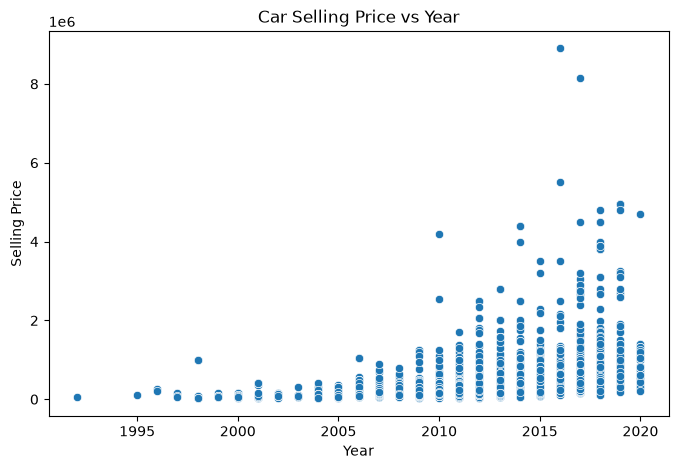

In [10]:
##price vs Year
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="year", y="selling_price")

plt.title("Car Selling Price vs Year")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

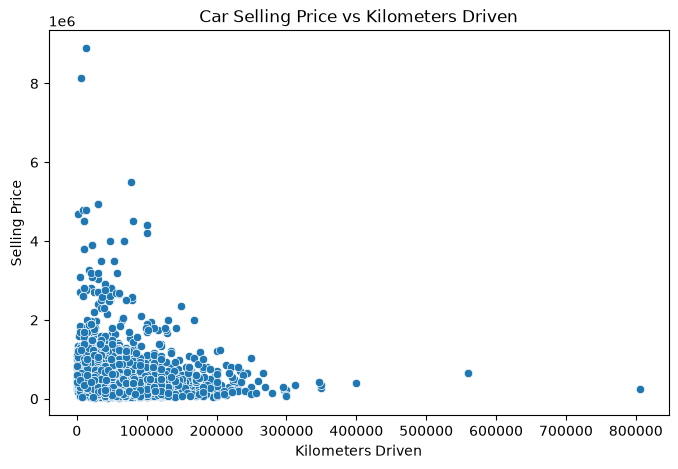

In [11]:
## Price vs Kilometers
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="km_driven", y="selling_price")

plt.title("Car Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

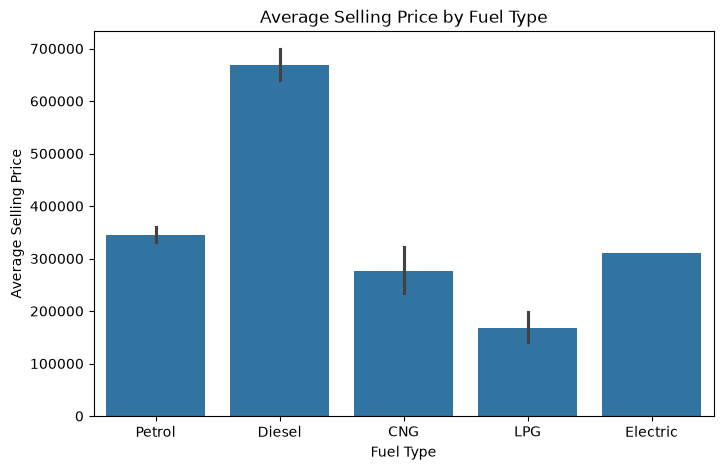

In [12]:
## Average price by fuel
plt.figure(figsize=(8,5))

sns.barplot(data=df, x="fuel", y="selling_price")

plt.title("Average Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Selling Price")
plt.show()

In [13]:
## Feature Engineering ##

# Car Age = Current Year - Manufacturing Year
df["car_age"] = 2026 - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [ ]:
## Select features ##
# Our target:
y = df["selling_price"]

In [16]:
# Features:
X = df[
    [
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ]
]

In [17]:
## Convert categorical variables to numerical
X = pd.get_dummies(X, drop_first=True)

X.head()

,car_age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,19,70000,False,False,False,True,True,False,True,False,False,False,False
1,19,50000,False,False,False,True,True,False,True,False,False,False,False
2,14,100000,True,False,False,False,True,False,True,False,False,False,False
3,9,46000,False,False,False,True,True,False,True,False,False,False,False
4,12,141000,True,False,False,False,True,False,True,False,True,False,False


In [18]:
print(X.columns)

Index(['car_age', 'km_driven', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG',
       'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'owner_Fourth & Above Owner',
       'owner_Second Owner', 'owner_Test Drive Car', 'owner_Third Owner'],
      dtype='str')


In [19]:
## Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3472, 13)
Testing data: (868, 13)


In [20]:
## Train 3 models

#linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

In [21]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

In [22]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

In [23]:
#compare the models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_test, prediction):
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

results = []

results.append(evaluate_model(
    "Linear Regression",
    y_test,
    lr_prediction
))

results.append(evaluate_model(
    "Decision Tree",
    y_test,
    dt_prediction
))

results.append(evaluate_model(
    "Random Forest",
    y_test,
    rf_prediction
))

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,221585.880225,426721.283110,0.403313
1,Decision Tree,178846.283540,434798.358008,0.380511
2,Random Forest,169615.571235,393073.930039,0.493702


In [24]:
#select the best model based on R2 score
results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,169615.571235,393073.930039,0.493702
0,Linear Regression,221585.880225,426721.283110,0.403313
1,Decision Tree,178846.283540,434798.358008,0.380511


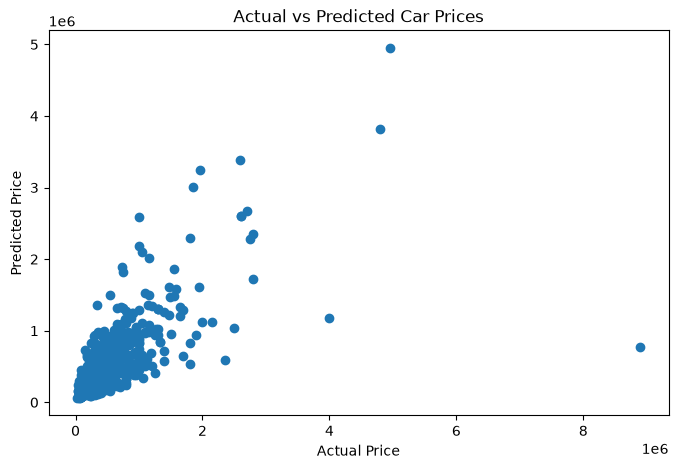

In [25]:
#Actual vs Predicted graph
plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_prediction)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [26]:
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,221585.880225,426721.283110,0.403313
1,Decision Tree,178846.283540,434798.358008,0.380511
2,Random Forest,169615.571235,393073.930039,0.493702


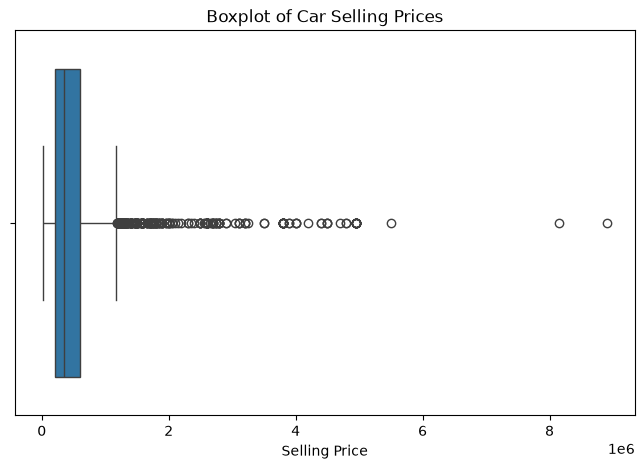

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["selling_price"])

plt.title("Boxplot of Car Selling Prices")
plt.xlabel("Selling Price")

plt.show()

In [28]:
df["selling_price"].describe()

count    4.340000e+03
mean     5.041273e+05
std      5.785487e+05
min      2.000000e+04
25%      2.087498e+05
50%      3.500000e+05
75%      6.000000e+05
max      8.900000e+06
Name: selling_price, dtype: float64

## Outlier Treatment

The selling price contains extreme values that can strongly influence the regression models. We will identify the upper bound using the IQR method and create a cleaned dataset for modeling.

In [29]:
Q1 = df["selling_price"].quantile(0.25)
Q3 = df["selling_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 208749.75
Q3: 600000.0
IQR: 391250.25
Lower Bound: -378125.625
Upper Bound: 1186875.375


In [30]:
df_clean = df[
    (df["selling_price"] >= lower_bound) &
    (df["selling_price"] <= upper_bound)
].copy()

print("Original dataset:", df.shape)
print("Cleaned dataset:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original dataset: (4340, 9)
Cleaned dataset: (4069, 9)
Rows removed: 271


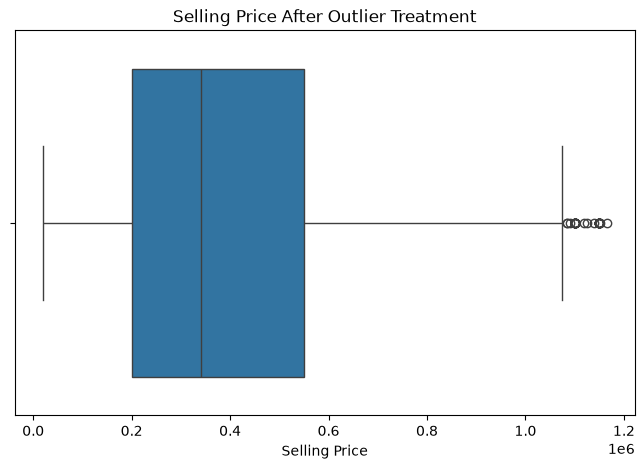

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_clean["selling_price"])

plt.title("Selling Price After Outlier Treatment")
plt.xlabel("Selling Price")

plt.show()

## Feature Engineering and Model Preparation

Car age is created from the manufacturing year. Categorical variables are converted into numerical values using one-hot encoding before training the machine learning models.

In [32]:
# Create car age
df_clean["car_age"] = 2026 - df_clean["year"]

# Select features
X_clean = df_clean[
    [
        "car_age",
        "km_driven",
        "fuel",
        "seller_type",
        "transmission",
        "owner"
    ]
]

# Target variable
y_clean = df_clean["selling_price"]

# Convert categorical variables
X_clean = pd.get_dummies(X_clean, drop_first=True)

print("Features:", X_clean.shape)
print("Target:", y_clean.shape)

Features: (4069, 13)
Target: (4069,)


In [33]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_clean.shape)
print("Testing data:", X_test_clean.shape)

Training data: (3255, 13)
Testing data: (814, 13)


In [34]:
# train the Random Forest Regressor again
from sklearn.ensemble import RandomForestRegressor

rf_clean = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_clean.fit(X_train_clean, y_train_clean)

rf_clean_prediction = rf_clean.predict(X_test_clean)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_clean = mean_absolute_error(y_test_clean, rf_clean_prediction)
rmse_clean = np.sqrt(mean_squared_error(y_test_clean, rf_clean_prediction))
r2_clean = r2_score(y_test_clean, rf_clean_prediction)

print("Random Forest After Outlier Treatment")
print("--------------------------------------")
print("MAE :", mae_clean)
print("RMSE:", rmse_clean)
print("R2 Score:", r2_clean)

Random Forest After Outlier Treatment
--------------------------------------
MAE : 112539.6300414335
RMSE: 163626.68613889368
R2 Score: 0.5378875314235358


## Final Model: Actual vs Predicted Prices

The Random Forest model after outlier treatment is selected as the final model based on its lower error and higher R² score.

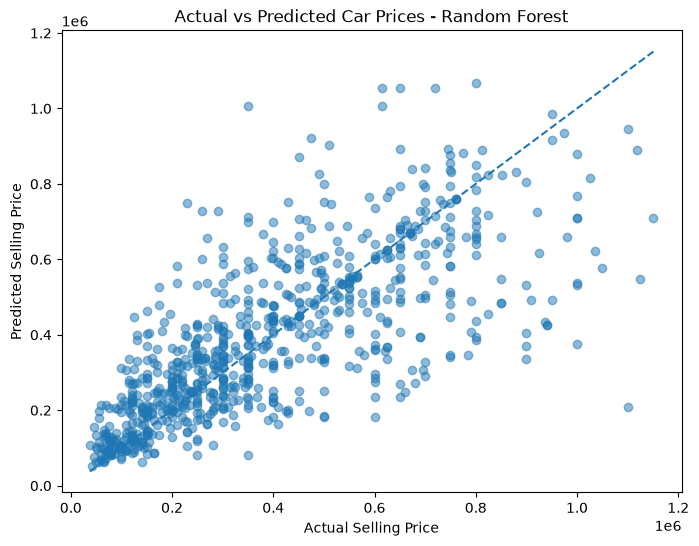

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_clean,
    rf_clean_prediction,
    alpha=0.5
)

plt.plot(
    [y_test_clean.min(), y_test_clean.max()],
    [y_test_clean.min(), y_test_clean.max()],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices - Random Forest")

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X_clean.columns,
    "Importance": rf_clean.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,car_age,0.520731
1,km_driven,0.241872
2,fuel_Diesel,0.108422
8,transmission_Manual,0.043031
10,owner_Second Owner,0.025806
6,seller_type_Individual,0.022247
7,seller_type_Trustmark Dealer,0.017323
12,owner_Third Owner,0.011264
11,owner_Test Drive Car,0.004301
9,owner_Fourth & Above Owner,0.002936


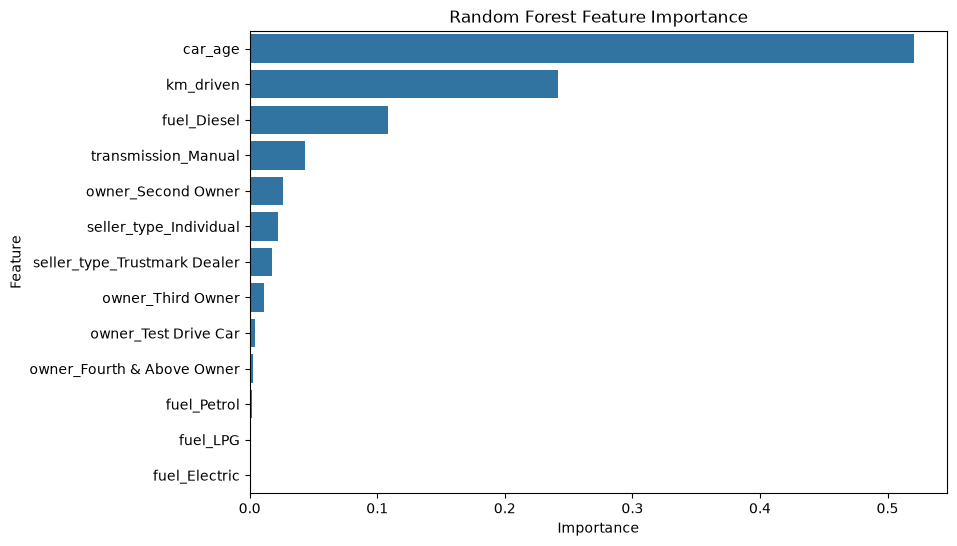

In [38]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [39]:
# Create final prediction dataset for Power BI

powerbi_df = X_test_clean.copy()

powerbi_df["Actual_Price"] = y_test_clean.values
powerbi_df["Predicted_Price"] = rf_clean_prediction
powerbi_df["Prediction_Error"] = (
    powerbi_df["Actual_Price"] - powerbi_df["Predicted_Price"]
)
powerbi_df["Absolute_Error"] = abs(powerbi_df["Prediction_Error"])

powerbi_df.head()

,car_age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,Actual_Price,Predicted_Price,Prediction_Error,Absolute_Error
3960,13,88000,True,False,False,False,True,False,True,False,True,False,False,430000,331724.027619,98275.972381,98275.972381
3611,14,235000,True,False,False,False,True,False,True,False,True,False,False,434999,435200.000000,-201.000000,201.000000
1585,16,110000,False,False,False,True,True,False,True,False,False,False,False,130000,137696.666667,-7696.666667,7696.666667
1205,12,40000,False,False,False,True,True,False,True,False,True,False,False,351000,214459.265714,136540.734286,136540.734286
2608,9,70000,False,False,False,True,True,False,True,False,True,False,False,600000,360024.666667,239975.333333,239975.333333


In [40]:
powerbi_df.to_csv("Car_Price_PowerBI.csv", index=False)

print("Power BI dataset saved successfully!")
print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))

Power BI dataset saved successfully!
Rows: 814
Columns: 17


In [41]:
import joblib

joblib.dump(rf_clean, "car_price_random_forest.pkl")

print("Final Random Forest model saved successfully!")

Final Random Forest model saved successfully!


In [42]:
print("Final Power BI dataset saved successfully!")
print("Final Random Forest model saved successfully!")
print("Project completed successfully!")

Final Power BI dataset saved successfully!
Final Random Forest model saved successfully!
Project completed successfully!
